In [12]:
# Notebook Testing - Plant Health Analysis
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, RocCurveDisplay)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SVM MODEL EVALUATION ON TEST SET")
print("Real-world performance validation")
print("Classes: 0=Healthy | 1=Moderate Stress | 2=High Stress")
print("="*60)

SVM MODEL EVALUATION ON TEST SET
Real-world performance validation
Classes: 0=Healthy | 1=Moderate Stress | 2=High Stress


In [13]:
# 1. LOAD TEST DATA AND MODEL
print("\n1. LOAD TEST DATA AND MODEL")
print("-"*50)

# Load test data
test_df = pd.read_csv('../data/processed/test_data.csv')
print(f"✓ Test data loaded: {test_df.shape}")

# Load the SVM model
with open('../model/svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)
print("✓ SVM model loaded")

# Load preprocessing objects
with open('../model/preprocessing_objects.pkl', 'rb') as f:
    preprocessing_objects = pickle.load(f)

label_encoder = preprocessing_objects['label_encoder']
feature_columns = preprocessing_objects['feature_columns']
scaler = preprocessing_objects['scaler']

print(f"✓ Preprocessing objects loaded")
print(f"✓ Classes: {list(label_encoder.classes_)}")
print(f"✓ Features: {len(feature_columns)}")


1. LOAD TEST DATA AND MODEL
--------------------------------------------------
✓ Test data loaded: (240, 15)
✓ SVM model loaded
✓ Preprocessing objects loaded
✓ Classes: [np.str_('Healthy'), np.str_('High Stress'), np.str_('Moderate Stress')]
✓ Features: 14


In [14]:
# 2. PREPARE TEST DATA
print("\n2. PREPARE TEST DATA")
print("-"*50)

X_test = test_df[feature_columns].values
y_test = test_df['Plant_Health_Status'].values

print(f"✓ X_test shape: {X_test.shape}")
print(f"✓ y_test shape: {y_test.shape}")
print(f"✓ Classes in y_test: {np.unique(y_test)}")

# Check class distribution
print("\n✓ Class distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    class_name = label_encoder.classes_[cls]
    percentage = count / len(y_test) * 100
    print(f"  - Class {cls} ({class_name}): {count} samples ({percentage:.1f}%)")


2. PREPARE TEST DATA
--------------------------------------------------
✓ X_test shape: (240, 14)
✓ y_test shape: (240,)
✓ Classes in y_test: [0 1 2]

✓ Class distribution in test set:
  - Class 0 (Healthy): 60 samples (25.0%)
  - Class 1 (High Stress): 100 samples (41.7%)
  - Class 2 (Moderate Stress): 80 samples (33.3%)


In [15]:
# 3. PREDICTIONS ON TEST SET
print("\n3. PREDICTIONS ON TEST SET")
print("-"*50)

y_test_pred = svm_model.predict(X_test)
y_test_proba = svm_model.predict_proba(X_test)

print("✓ Predictions completed:")
print(f"  - Predictions shape: {y_test_pred.shape}")
print(f"  - Probabilities shape: {y_test_proba.shape}")


3. PREDICTIONS ON TEST SET
--------------------------------------------------
✓ Predictions completed:
  - Predictions shape: (240,)
  - Probabilities shape: (240, 3)


In [16]:
# 4. PERFORMANCE EVALUATION
print("\n4. PERFORMANCE EVALUATION")
print("-"*50)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')

print("✓ Main metrics:")
print(f"  - Accuracy:  {test_accuracy:.4f}")
print(f"  - F1-Score:  {test_f1:.4f}")
print(f"  - Precision: {test_precision:.4f}")
print(f"  - Recall:    {test_recall:.4f}")


4. PERFORMANCE EVALUATION
--------------------------------------------------
✓ Main metrics:
  - Accuracy:  0.7375
  - F1-Score:  0.7404
  - Precision: 0.7471
  - Recall:    0.7375


In [17]:
# 5. DETAILED CLASSIFICATION REPORT
print("\n5. DETAILED CLASSIFICATION REPORT")
print("-"*50)

print("Classification report (Test Set):")
print(classification_report(y_test, y_test_pred,
                            target_names=label_encoder.classes_))

print("✓ Metrics per class:")
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test == i
    if np.sum(class_mask) > 0:
        class_accuracy = accuracy_score(y_test[class_mask], y_test_pred[class_mask])
        class_f1 = f1_score(y_test[class_mask], y_test_pred[class_mask], average='weighted')
        print(f"  - {class_name}: Accuracy={class_accuracy:.3f}, F1={class_f1:.3f}")


5. DETAILED CLASSIFICATION REPORT
--------------------------------------------------
Classification report (Test Set):
                 precision    recall  f1-score   support

        Healthy       0.75      0.73      0.74        60
    High Stress       0.84      0.76      0.80       100
Moderate Stress       0.63      0.71      0.67        80

       accuracy                           0.74       240
      macro avg       0.74      0.74      0.74       240
   weighted avg       0.75      0.74      0.74       240

✓ Metrics per class:
  - Healthy: Accuracy=0.733, F1=0.846
  - High Stress: Accuracy=0.760, F1=0.864
  - Moderate Stress: Accuracy=0.713, F1=0.832



6. CONFUSION MATRIX
--------------------------------------------------
✓ Confusion matrix saved: model/svm_confusion_matrix_test.png


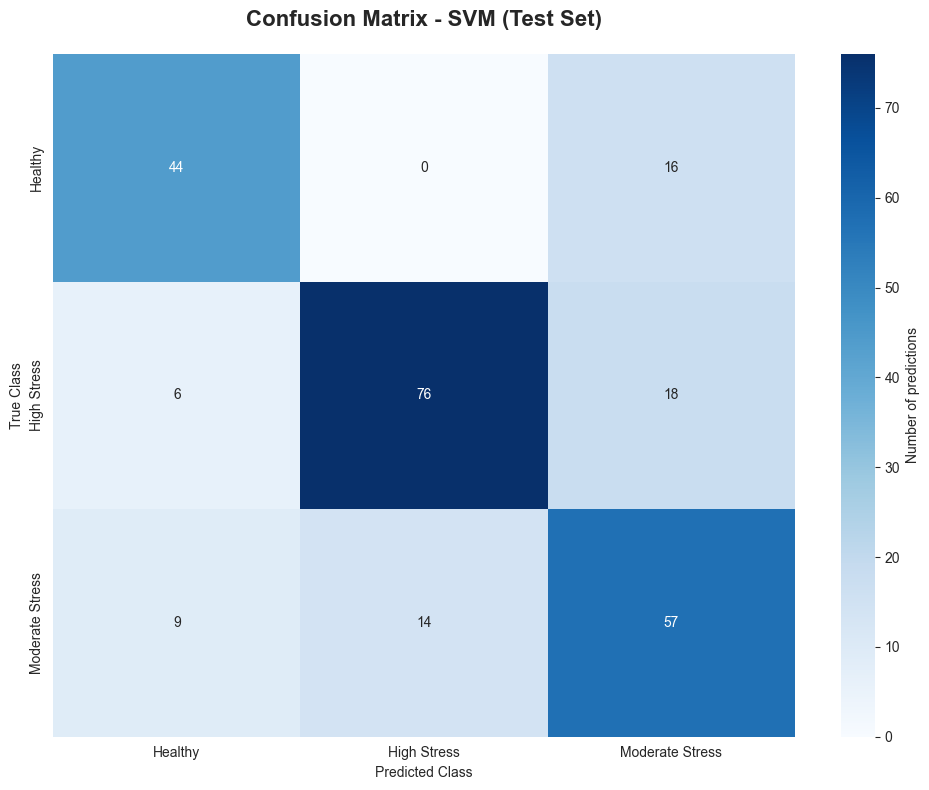

In [18]:
# 6. CONFUSION MATRIX
print("\n6. CONFUSION MATRIX")
print("-"*50)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of predictions'})

plt.title('Confusion Matrix - SVM (Test Set)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('../model/svm_confusion_matrix_test.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved: model/svm_confusion_matrix_test.png")
plt.show()


7. ROC CURVES ON TEST SET
--------------------------------------------------
✓ ROC curves saved: model/svm_roc_curves_test.png


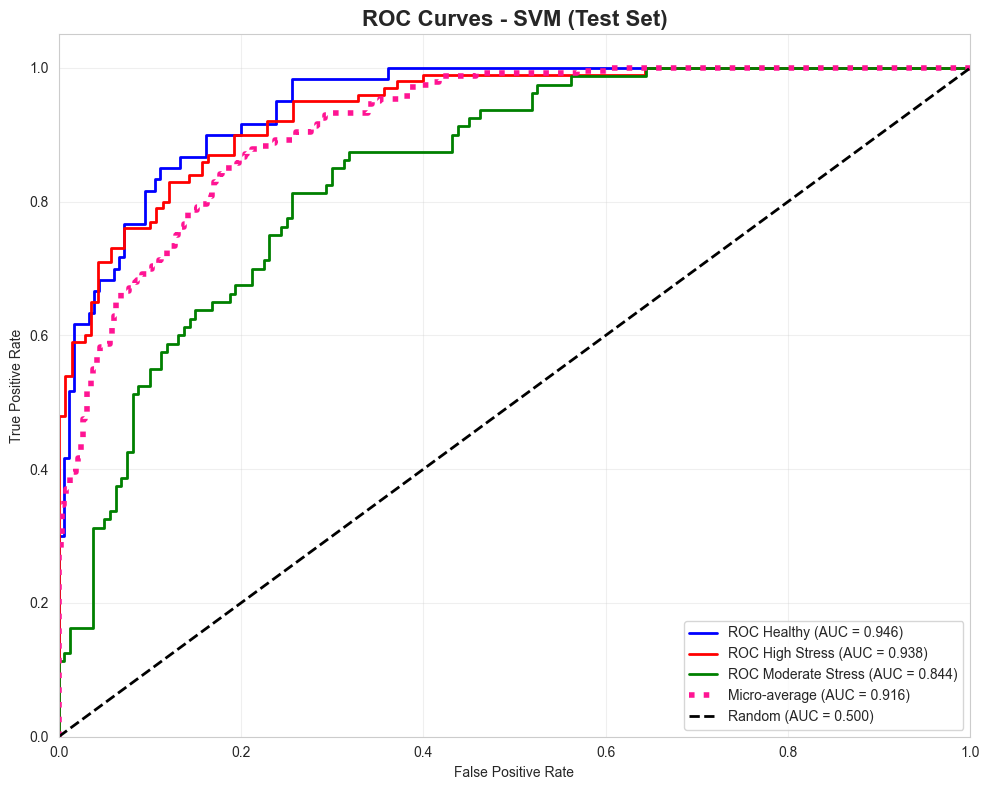


✓ ROC-AUC per class (Test Set):
  - Healthy: 0.9465 (🎯 Excellent)
  - High Stress: 0.9377 (🎯 Excellent)
  - Moderate Stress: 0.8437 (✅ Good)
  - Micro-average: 0.9162


In [19]:
# 7. ROC CURVES ON TEST SET
print("\n7. ROC CURVES ON TEST SET")
print("-"*50)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = len(label_encoder.classes_)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_test_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC {0} (AUC = {1:0.3f})'
             .format(label_encoder.classes_[i], roc_auc[i]))

plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-average (AUC = {0:0.3f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - SVM (Test Set)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../model/svm_roc_curves_test.png', dpi=300, bbox_inches='tight')
print("✓ ROC curves saved: model/svm_roc_curves_test.png")
plt.show()

print("\n✓ ROC-AUC per class (Test Set):")
for i in range(n_classes):
    auc_value = roc_auc[i]
    if auc_value >= 0.9:
        interpretation = "🎯 Excellent"
    elif auc_value >= 0.8:
        interpretation = "✅ Good"
    elif auc_value >= 0.7:
        interpretation = "⚠️ Acceptable"
    else:
        interpretation = "❌ Poor"
    print(f"  - {label_encoder.classes_[i]}: {auc_value:.4f} ({interpretation})")
print(f"  - Micro-average: {roc_auc['micro']:.4f}")

In [20]:
# 8. SAVE TEST RESULTS
print("\n9. SAVE TEST RESULTS")
print("-"*50)

test_results = {
    'test_metrics': {
        'accuracy': test_accuracy,
        'f1_score': test_f1,
        'precision': test_precision,
        'recall': test_recall
    },
    'roc_auc_test': roc_auc,
    'confusion_matrix': cm.tolist(),
    'error_analysis': {
        'total_errors': len(incorrect_indices),
        'error_rate': len(incorrect_indices) / len(y_test),
        'error_by_class': error_by_true_class if len(incorrect_indices) > 0 else {}
    },
    'test_set_size': len(X_test),
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

test_results_path = '../model/svm_test_results.pkl'
with open(test_results_path, 'wb') as f:
    pickle.dump(test_results, f)
print(f"✓ Test results saved: {test_results_path}")


9. SAVE TEST RESULTS
--------------------------------------------------
✓ Test results saved: ../model/svm_test_results.pkl
